In [6]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Dropout

Training model...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 0.0257
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0082
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0077
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0086
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0109
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0083
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0073
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0066
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0059
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0046
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0043
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0037
Epoch 13/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0032
Epoch 14/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0045
Epoch 15/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0032
Epoch 16/50
96/

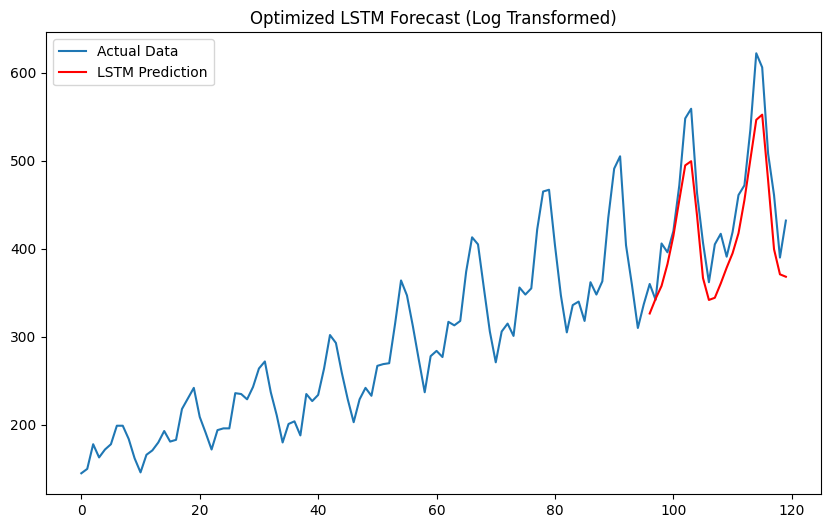

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
--- LSTM LIVE DEMO (Sample 0) ---
Model Input (Past Data): [314 301 356 347 355 422 465 467 403 347 304 335 340 318 362 347 363 434
 490 504 403 358 310 337]
Model Prediction: 326
Actual Value:     360
Difference:       34 passengers
Result: NEEDS IMPROVEMENT ⚠️


In [22]:
class AirlineModel:
    def __init__(self,file_path,look_back=24,test_size = 0.3):
        self.file_path = file_path
        self.look_back = look_back
        self.scaler = MinMaxScaler(feature_range=(0,1))
        self.model = None

    def load_and_prepare(self):
        df = pd.read_csv(self.file_path, usecols=[1])
        # STEP 1: Apply Log Transformation here
        data = np.log(df.values.astype('float32'))

        scaled_data = self.scaler.fit_transform(data)

        X, y = [], []
        for i in range(len(scaled_data) - self.look_back):
            X.append(scaled_data[i:(i + self.look_back), 0])
            y.append(scaled_data[i + self.look_back, 0])
        X, y = np.array(X), np.array(y)

        self.X = np.reshape(X, (X.shape[0], X.shape[1], 1))
        self.y = y

        train_size = int(len(self.X) * 0.8)
        self.X_train, self.X_test = self.X[:train_size], self.X[train_size:]
        self.y_train, self.y_test = self.y[:train_size], self.y[train_size:]


# Add this inside your AirlineModel class
    def build_and_train(self, epochs=50):
        model = Sequential([LSTM(100, activation='tanh',return_sequences=True, input_shape=(self.look_back, 1)),
             Dropout(0.1),
             LSTM(50,activation='tanh'),
             Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')

        print("Training model...")
        model.fit(self.X_train, self.y_train, epochs=epochs, batch_size=1, verbose=1)
        self.model = model  # This line "saves" the model so evaluate() can see it


    def evaluate(self):
        print("Predicting...")
        train_predict = self.model.predict(self.X_train)
        test_predict = self.model.predict(self.X_test)

        # STEP 2: Inverse transform AND then apply np.exp()
        train_predict = np.exp(self.scaler.inverse_transform(train_predict))
        test_predict = np.exp(self.scaler.inverse_transform(test_predict))
        actual_data = np.exp(self.scaler.inverse_transform(self.y.reshape(-1,1)))

        plt.figure(figsize=(10,6))
        plt.plot(actual_data, label="Actual Data")

        test_plot = np.empty_like(self.y).reshape(-1,1)
        test_plot[:, :] = np.nan
        test_plot[len(train_predict):len(self.y), :] = test_predict

        plt.plot(test_plot, label="LSTM Prediction", color='red')
        plt.title("Optimized LSTM Forecast (Log Transformed)")
        plt.legend()
        plt.show()

    def rnn_prediction_demo(self, sample_index=0):
        input_sequence = self.X_test[sample_index].reshape(1, self.X_test.shape[1], 1)
        scaled_prediction = self.model.predict(input_sequence)

        # STEP 3: Apply np.exp() to get real passenger counts back
        prediction = np.exp(self.scaler.inverse_transform(scaled_prediction))[0][0]
        actual = np.exp(self.scaler.inverse_transform(self.y_test[sample_index].reshape(-1, 1)))[0][0]

        print(f"--- LSTM LIVE DEMO (Sample {sample_index}) ---")
        # For the input display, we also need to exp() it
        past_data = np.exp(self.scaler.inverse_transform(self.X_test[sample_index])).flatten().astype(int)
        print(f"Model Input (Past Data): {past_data}")
        print(f"Model Prediction: {round(prediction)}")
        print(f"Actual Value:     {actual:.0f}")

        error = abs(prediction - actual)
        print(f"Difference:       {round(error)} passengers")

        if error < 15:
            print("Result: EXCELLENT ")
        else:
            print("Result: NEEDS IMPROVEMENT ")

DATA_URL = 'airline-passengers.csv'
rnn_project = AirlineModel(DATA_URL)
rnn_project.load_and_prepare()
rnn_project.build_and_train(epochs=50)
rnn_project.evaluate()
rnn_project.rnn_prediction_demo()


